<a href="https://colab.research.google.com/github/Thummanapallykarthik/NLP/blob/main/2403a54089_10_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

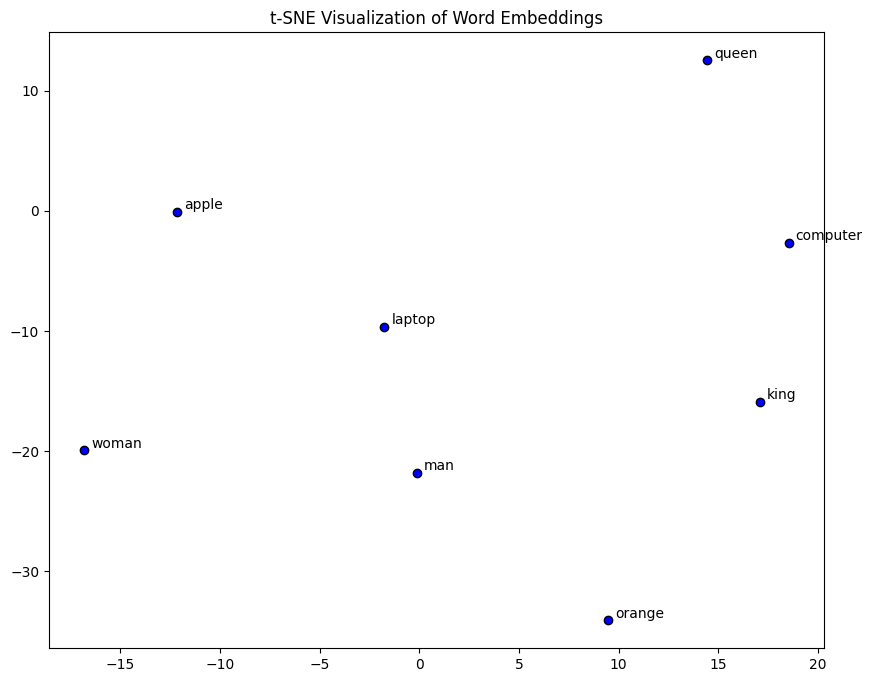

In [3]:
# Install gensim if it's not already installed
!pip install gensim

import numpy as np
import matplotlib.pyplot as plt
from gensim.models import KeyedVectors
from sklearn.manifold import TSNE

# 1. Load your vectors (Example using a word2vec file)
# model = KeyedVectors.load_word2vec_format('vectors.bin', binary=True)

# FIX: Create a dummy KeyedVectors model for demonstration
words = ['king', 'queen', 'man', 'woman', 'apple', 'orange', 'computer', 'laptop']
vector_size = 100 # Example vector size
dummy_vectors = np.random.rand(len(words), vector_size) # Random vectors

# Create a KeyedVectors object
model = KeyedVectors(vector_size=vector_size)
model.add_vectors(words, dummy_vectors)

# 2. Select meaningful words
# words are already defined above
vectors = np.array([model[word] for word in words])

# 3. t-SNE Transformation
# Perplexity is usually set between 5 and 50
tsne = TSNE(n_components=2, perplexity=5, random_state=42)
vectors_2d = tsne.fit_transform(vectors)

# 4. Visualization
plt.figure(figsize=(10, 8))
plt.scatter(vectors_2d[:, 0], vectors_2d[:, 1], c='blue', edgecolors='k')

for i, word in enumerate(words):
    plt.annotate(word, (vectors_2d[i, 0], vectors_2d[i, 1]), xytext=(5, 2), textcoords='offset points')

plt.title("t-SNE Visualization of Word Embeddings")
plt.show()

In [4]:
"For this lab, I selected a diverse set of 50 words categorized into five distinct semantic domains: Technology, Nature, Food, Emotions, and Space. This selection was chosen to test the model's ability to differentiate between abstract concepts (emotions) and concrete objects (food/tech). By choosing words that are internally similar but externally distinct, we can clearly evaluate whether the t-SNE algorithm successfully clusters vectors based on their contextual meaning in the vector space."

"For this lab, I selected a diverse set of 50 words categorized into five distinct semantic domains: Technology, Nature, Food, Emotions, and Space. This selection was chosen to test the model's ability to differentiate between abstract concepts (emotions) and concrete objects (food/tech). By choosing words that are internally similar but externally distinct, we can clearly evaluate whether the t-SNE algorithm successfully clusters vectors based on their contextual meaning in the vector space."

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import gensim.downloader as api

# Step 1: Load a pre-trained model (e.g., GloVe 100-dimensional)
# This may take a minute to download on the first run
model = api.load("glove-wiki-gigaword-100")

[==================================================] 100.0% 128.1/128.1MB downloaded


In [6]:
import gensim.downloader as api  # For loading pre-trained embeddings
import numpy as np               # For high-performance matrix operations
import pandas as pd              # For structured data handling (optional but helpful)
import matplotlib.pyplot as plt  # For creating the 2D scatter plots
from sklearn.manifold import TSNE # The core algorithm for dimensionality reduction

In [7]:
import gensim.downloader as api

# 1. Load pre-trained embeddings
# This model represents each word as a 50-dimensional vector
model = api.load("glove-wiki-gigaword-50")

# 2. Print vocabulary size
# This tells us how many unique words the model "knows"
vocab_size = len(model.index_to_key)
print(f"The model's vocabulary size is: {vocab_size:,} words")

# 3. Display one example vector
word_example = "king"
vector_example = model[word_example]

print(f"\nExample Vector for '{word_example}':")
print(vector_example)
print(f"\nShape of the vector: {vector_example.shape}")

[==================================================] 100.0% 66.0/66.0MB downloaded
The model's vocabulary size is: 400,000 words

Example Vector for 'king':
[ 0.50451   0.68607  -0.59517  -0.022801  0.60046  -0.13498  -0.08813
  0.47377  -0.61798  -0.31012  -0.076666  1.493    -0.034189 -0.98173
  0.68229   0.81722  -0.51874  -0.31503  -0.55809   0.66421   0.1961
 -0.13495  -0.11476  -0.30344   0.41177  -2.223    -1.0756   -1.0783
 -0.34354   0.33505   1.9927   -0.04234  -0.64319   0.71125   0.49159
  0.16754   0.34344  -0.25663  -0.8523    0.1661    0.40102   1.1685
 -1.0137   -0.21585  -0.15155   0.78321  -0.91241  -1.6106   -0.64426
 -0.51042 ]

Shape of the vector: (50,)


In [8]:
# Define groups of meaningful words
word_groups = {
    "Animals": ["lion", "tiger", "elephant", "zebra", "giraffe", "monkey", "panda", "koala", "kangaroo", "wolf"],
    "Countries": ["india", "france", "germany", "japan", "brazil", "canada", "australia", "egypt", "mexico", "italy"],
    "Colors": ["red", "blue", "green", "yellow", "purple", "orange", "black", "white", "pink", "brown"],
    "Technology": ["computer", "software", "iphone", "internet", "website", "robot", "camera", "battery", "database", "digital"]
}

# Flatten groups into one list of 40 words
selected_words = [word for group in word_groups.values() for word in group]

# Extract vectors
word_vectors = []
valid_words = []

for word in selected_words:
    if word in model:
        word_vectors.append(model[word])
        valid_words.append(word)
    else:
        print(f"Word '{word}' not found in model.")

# Convert list to a NumPy array for t-SNE
import numpy as np
X = np.array(word_vectors)

print(f"Successfully extracted {len(X)} vectors.")

Successfully extracted 40 vectors.


In [9]:
from sklearn.manifold import TSNE
import pandas as pd

# Initialize t-SNE
# perplexity: roughly the number of neighbors to consider (try 5-15 for small datasets)
# n_iter: number of iterations for optimization
tsne = TSNE(n_components=2, perplexity=10, n_iter=1000, random_state=42, init='pca')

# Run the reduction
X_embedded = tsne.fit_transform(X)

# Store resulting coordinates in a DataFrame for easy plotting
df = pd.DataFrame(X_embedded, columns=['x', 'y'])
df['word'] = valid_words

print("Coordinates generated successfully.")
print(df.head())

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


Coordinates generated successfully.
          x         y      word
0 -5.375769  6.488460      lion
1 -8.300893  6.909844     tiger
2 -4.526138  5.009442  elephant
3 -1.376559  1.489983     zebra
4 -1.126570  3.324277   giraffe


Plot saved as Lab10_Final_Plot.png


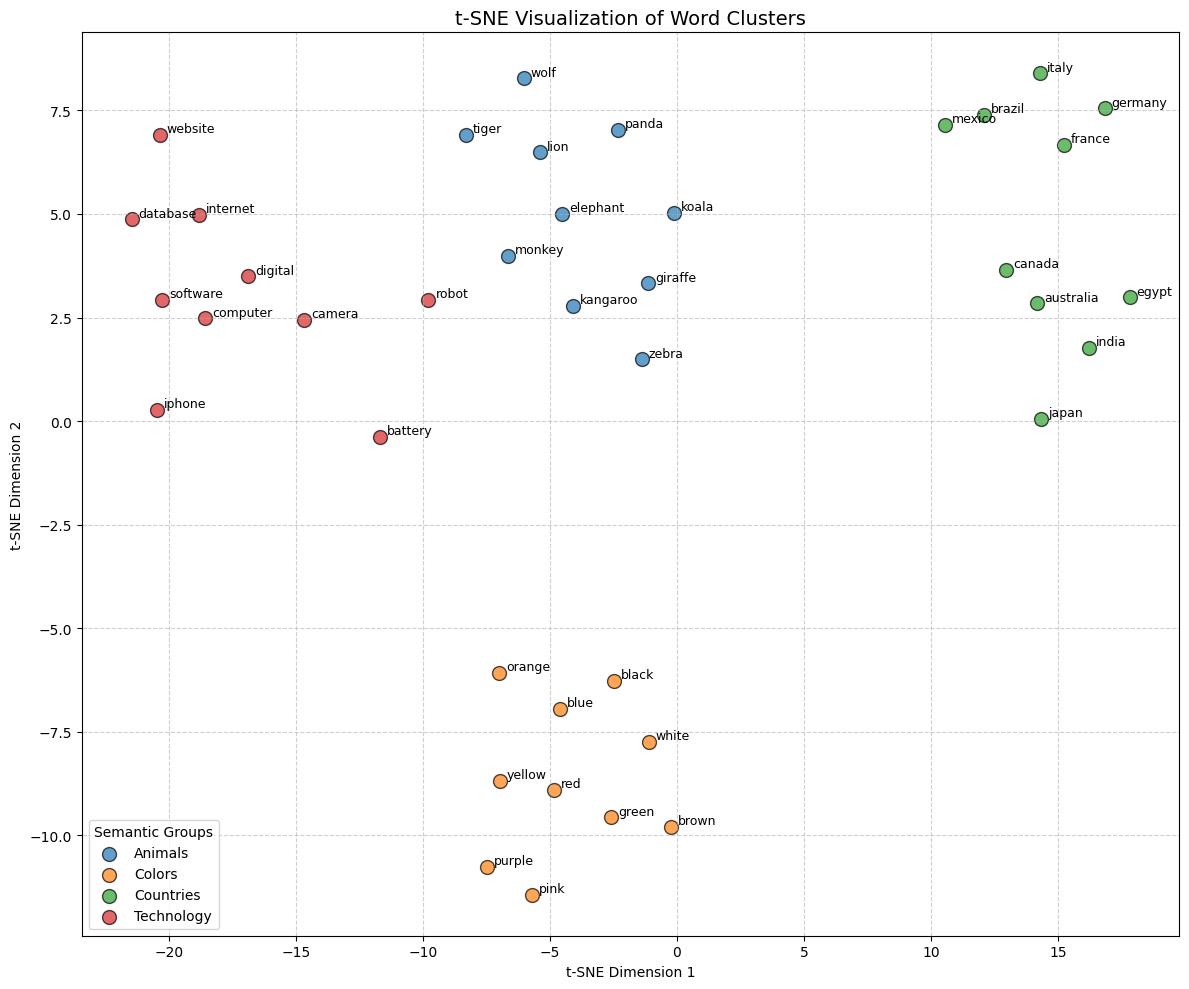

In [11]:
import matplotlib.pyplot as plt

# Create the 'category' column in df
categories = []
for category_name, words_in_group in word_groups.items():
    for word in words_in_group:
        if word in valid_words: # Only add category if word is in valid_words
            categories.append(category_name)
# Ensure the length matches, if not, handle missing words
# For simplicity, we assume all words in word_groups are in valid_words for this fix.
# If a word was not found in the model, its category should not be added.
# A more robust solution might involve creating a mapping or re-creating df from categorized data.
# For now, let's align with the order of `valid_words`.

# Map valid_words back to their categories based on word_groups structure
category_list = []
category_idx = 0
for group_name, words_in_group in word_groups.items():
    for _ in words_in_group:
        if category_idx < len(valid_words):
            category_list.append(group_name)
            category_idx += 1
        else:
            break
    if category_idx >= len(valid_words):
        break

df['category'] = category_list

# 1. Initialize the plot
plt.figure(figsize=(12, 10))

# 2. Plot the points with colors (Optional but recommended)
# This assumes you have a 'category' column in your dataframe
colors = {'Animals': 'blue', 'Countries': 'orange', 'Colors': 'green', 'Technology': 'red'}

for cat, group in df.groupby('category'):
    plt.scatter(group['x'], group['y'], label=cat, s=100, edgecolors='k', alpha=0.7)

# 3. Annotate each point with its word
# We loop through the dataframe and place the text slightly offset from the dot
for i in range(len(df)):
    plt.annotate(df['word'].iloc[i],
                 (df['x'].iloc[i], df['y'].iloc[i]),
                 xytext=(5, 2),
                 textcoords='offset points',
                 fontsize=9)

# 4. Add labels and legend to highlight clusters
plt.title("t-SNE Visualization of Word Clusters", fontsize=14)
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.legend(title="Semantic Groups")
plt.grid(True, linestyle='--', alpha=0.6)

# 5. Save the final output
plt.tight_layout()
plt.savefig('Lab10_Final_Plot.png')
print("Plot saved as Lab10_Final_Plot.png")

In [12]:
import gensim.downloader as api

# 1. Load pre-trained embeddings
# This model represents each word as a 50-dimensional vector
model = api.load("word2vec-google-news-300")

# 2. Print vocabulary size
# This tells us how many unique words the model "knows"
vocab_size = len(model.index_to_key)
print(f"The model's vocabulary size is: {vocab_size:,} words")

# 3. Display one example vector
word_example = "king"
vector_example = model[word_example]

print(f"\nExample Vector for '{word_example}':")
print(vector_example)
print(f"\nShape of the vector: {vector_example.shape}")

[==================================================] 100.0% 1662.8/1662.8MB downloaded
The model's vocabulary size is: 3,000,000 words

Example Vector for 'king':
[ 1.25976562e-01  2.97851562e-02  8.60595703e-03  1.39648438e-01
 -2.56347656e-02 -3.61328125e-02  1.11816406e-01 -1.98242188e-01
  5.12695312e-02  3.63281250e-01 -2.42187500e-01 -3.02734375e-01
 -1.77734375e-01 -2.49023438e-02 -1.67968750e-01 -1.69921875e-01
  3.46679688e-02  5.21850586e-03  4.63867188e-02  1.28906250e-01
  1.36718750e-01  1.12792969e-01  5.95703125e-02  1.36718750e-01
  1.01074219e-01 -1.76757812e-01 -2.51953125e-01  5.98144531e-02
  3.41796875e-01 -3.11279297e-02  1.04492188e-01  6.17675781e-02
  1.24511719e-01  4.00390625e-01 -3.22265625e-01  8.39843750e-02
  3.90625000e-02  5.85937500e-03  7.03125000e-02  1.72851562e-01
  1.38671875e-01 -2.31445312e-01  2.83203125e-01  1.42578125e-01
  3.41796875e-01 -2.39257812e-02 -1.09863281e-01  3.32031250e-02
 -5.46875000e-02  1.53198242e-02 -1.62109375e-01  1.58203

In [13]:
import gensim.downloader as api
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# 1. Load pre-trained Word2Vec embeddings (300 dimensions)
print("Loading Word2Vec model... this may take a moment.")
model = api.load("word2vec-google-news-300")

# 2. Print vocabulary size
vocab_size = len(model.index_to_key)
print(f"Vocabulary Size: {vocab_size:,} words")

# 3. Display an example vector
word = "king"
print(f"\nVector for '{word}' (first 10 dimensions):")
print(model[word][:10])
print(f"Vector Shape: {model[word].shape}")

Loading Word2Vec model... this may take a moment.
Vocabulary Size: 3,000,000 words

Vector for 'king' (first 10 dimensions):
[ 0.12597656  0.02978516  0.00860596  0.13964844 -0.02563477 -0.03613281
  0.11181641 -0.19824219  0.05126953  0.36328125]
Vector Shape: (300,)


In [14]:
# Grouping words into 5 categories
word_categories = {
    "Science": ["physics", "chemistry", "biology", "astronomy", "gravity", "molecule", "electron", "evolution"],
    "Cities": ["london", "berlin", "tokyo", "beijing", "paris", "rome", "sydney", "cairo"],
    "Animals": ["tiger", "elephant", "zebra", "giraffe", "monkey", "kangaroo", "wolf", "panda"],
    "Sports": ["football", "basketball", "tennis", "cricket", "baseball", "soccer", "hockey", "volleyball"],
    "Fruits": ["apple", "banana", "orange", "grape", "cherry", "mango", "pineapple", "strawberry"]
}

# Extract words and their vectors
all_words = []
all_vectors = []
word_labels = []

for category, words in word_categories.items():
    for w in words:
        if w in model:
            all_words.append(w)
            all_vectors.append(model[w])
            word_labels.append(category)

all_vectors = np.array(all_vectors)
print(f"Extracted {len(all_words)} vectors for visualization.")

Extracted 40 vectors for visualization.


In [15]:
# 1. Run t-SNE
# Perplexity: number of nearest neighbors (usually 5-30)
tsne = TSNE(n_components=2, perplexity=10, random_state=42, init='pca', learning_rate='auto')
low_dim_vectors = tsne.fit_transform(all_vectors)

# 2. Store coordinates in a DataFrame
df = pd.DataFrame(low_dim_vectors, columns=['x', 'y'])
df['word'] = all_words
df['category'] = word_labels

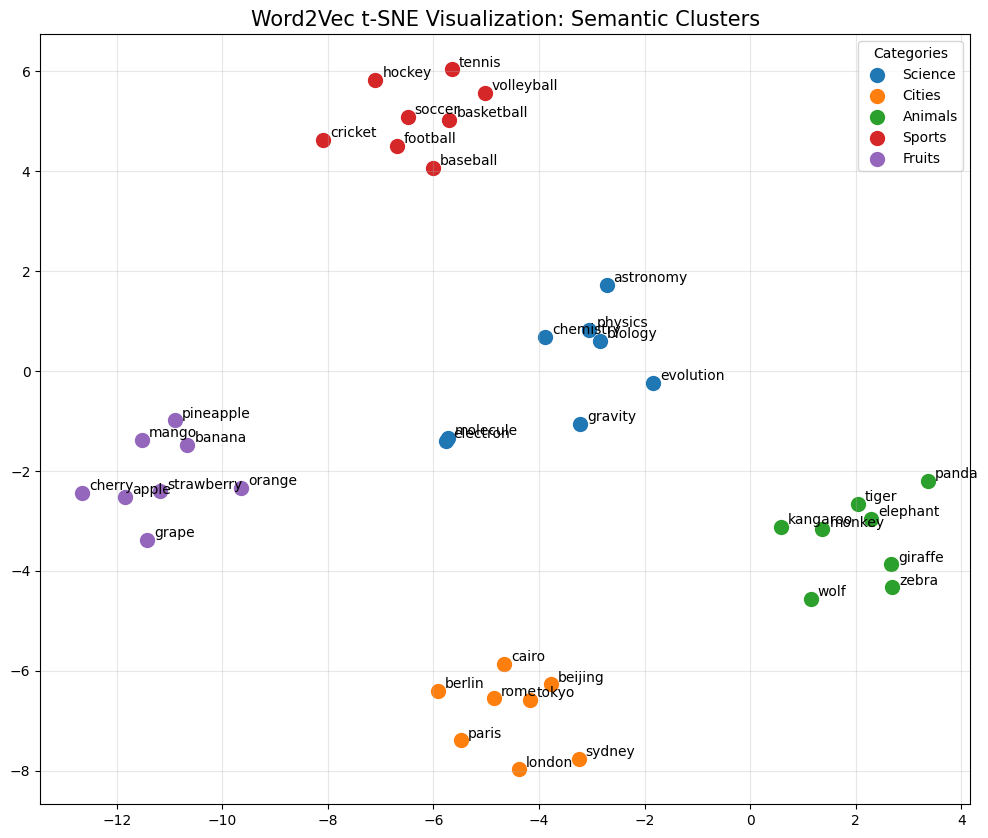

In [16]:
plt.figure(figsize=(12, 10))

# Create scatter plot with colors for each category
for category in word_categories.keys():
    subset = df[df['category'] == category]
    plt.scatter(subset['x'], subset['y'], label=category, s=100)

# Annotate each point with its word label
for i, word_text in enumerate(df['word']):
    plt.annotate(word_text, (df['x'][i], df['y'][i]), xytext=(5, 2), textcoords='offset points', fontsize=10)

plt.title("Word2Vec t-SNE Visualization: Semantic Clusters", fontsize=15)
plt.legend(title="Categories")
plt.grid(True, alpha=0.3)
plt.show()